# Part 7 — Applicability Domain & Virtual Screening

**Goal:** Define the chemical space where the model's predictions are
trustworthy, then use it to screen candidate compounds.

## What is the Applicability Domain (AD)?

A QSAR model is not equally reliable across all possible molecules.
The AD is the region of chemical space where the model has enough
structural information to make confident predictions.
Predictions *outside* the AD should be treated as extrapolations — the
model is predicting molecular behaviour for a structural class it has
never seen.

This is especially important for EGFR because the three inhibitor
generations are structurally distinct:
- **1st gen** (Erlotinib, Gefitinib) — quinazoline scaffolds, reversible
- **2nd gen** (Afatinib) — acrylamide warhead, covalent
- **3rd gen** (Osimertinib) — pyrimidine-indole, targets T790M mutation

A model trained mostly on 1st gen compounds will have a narrow AD that
excludes 3rd gen structures. The Williams plot and UMAP will show this.

## Two AD methods used here
1. **Leverage / Williams plot** — classical QSAR AD based on hat matrix diagonal. 
2. **Tanimoto distance to training set centroid** — fingerprint-based AD,
   more interpretable chemically

---
## 0. Installs & Imports

In [30]:
import numpy as np
import pandas as pd
import pickle
import warnings
warnings.filterwarnings('ignore')

from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, Draw
from scipy.stats import gaussian_kde
from rdkit.Chem import rdFingerprintGenerator
from rdkit.ML.Cluster import Butina
from sklearn.model_selection import BaseCrossValidator
from sklearn.metrics import r2_score, mean_squared_error
from scipy.stats import pearsonr

import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D
import seaborn as sns

import umap

print('All imports OK')

All imports OK


---
## 1. Load Data

In [31]:
# ── Model ─────────────────────────────────────────────────────────────────────
with open('../models/best_model_part5.pkl', 'rb') as f:
    model = pickle.load(f)
print(f'Model loaded: {type(model).__name__}')

# ── Feature matrix ────────────────────────────────────────────────────────────
X_df    = pd.read_csv('../data/processed/X_ecfp6.csv')
mol_ids = X_df['molecule_chembl_id'].reset_index(drop=True)
X       = X_df.drop(columns='molecule_chembl_id').values.astype(np.float32)

# ── Targets ───────────────────────────────────────────────────────────────────
y_pchembl_df = pd.read_csv('../data/processed/y_pchembl.csv').set_index('molecule_chembl_id')
y_reg        = y_pchembl_df.loc[mol_ids, 'pchembl_value'].values

# ── Cleaned dataset (for SMILES and class labels) ─────────────────────────────
df_clean = pd.read_csv('../data/processed/egfr_bioactivity_cleaned.csv').set_index('molecule_chembl_id')
df_clean = df_clean.loc[mol_ids].reset_index()

# ── Butina cluster IDs ────────────────────────────────────────────────────────
cluster_ids = np.load('../data/cluster_id/butina_cluster_ids_reg.npy')

print(f'X shape       : {X.shape}')
print(f'Compounds     : {len(mol_ids)}')
print(f'Class balance : {df_clean["bioactivity_class"].value_counts().to_dict()}')

Model loaded: XGBRegressor
X shape       : (9876, 339)
Compounds     : 9876
Class balance : {'active': 7439, 'intermediate': 1722, 'inactive': 715}


In [32]:
# ── Build Mol objects ─────────────────────
mols = [Chem.MolFromSmiles(smi) for smi in df_clean['canonical_smiles']]
n_invalid = sum(1 for m in mols if m is None)
print(f'Valid molecules: {len(mols) - n_invalid} / {len(mols)}')

# ── Compute ECFP6 as RDKit bit vectors (needed for Tanimoto) ─────────────────
fpg = rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=2048)
fps = [fpg.GetFingerprint(mol) for mol in mols if mol is not None]

Valid molecules: 9876 / 9876


---
## 2. Split — Last Butina Fold as Test Set

For the AD analysis we need a  held-out test set.
We use the last fold from our Butina CV as a proxy — it is the
structurally most distant set from the training data by construction.

In [33]:
from src.models import ButinaCrossValidator

cv = ButinaCrossValidator(n_splits=5)
splits = list(cv.split(X, y_reg, groups=cluster_ids))
train_idx, test_idx = splits[-1]   # last fold = most novel test set

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y_reg[train_idx], y_reg[test_idx]

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'Test fold: {len(test_idx)} compounds')
print(f'R² = {r2:.3f}   RMSE = {rmse:.3f} pChEMBL')

Test fold: 1889 compounds
R² = 0.734   RMSE = 0.667 pChEMBL


---

## 3. Applicability Domain — Method 1: Leverage (Williams Plot)

**Theory:**
The leverage of a compound measures how "unusual" it is relative
to the training set in feature space.

For a feature matrix X, the hat matrix is:

```
H = X (X'X)⁻¹ X'
```

The diagonal `h_i` is the leverage of compound i.
High leverage = far from the training data centroid in ECFP6 space.

**Williams plot:**
Scatter of standardised residuals (y-axis) vs leverage (x-axis).
The warning threshold is:

```
h* = 3(k+1)/n   where k = features, n = training set size
```

Compounds with h > h* are **outside the AD** — predictions are extrapolations.

**Important limitation:**
Although the Williams plot is a standard approach for defining the AD,
it relies on Euclidean geometry and continuous feature assumptions. In this work,
we use high-dimensional (2048-bit) sparse binary ECFP6 fingerprints, where these
assumptions do not hold.

In such spaces:

* Distances become less informative due to the curse of dimensionality
* Binary sparsity leads to distorted notions of similarity under linear projections
* Chemical similarity is better captured by metrics such as Tanimoto similarity rather than Euclidean distance


**Practical note:**
With 2048 ECFP6 bits, the full hat matrix is computationally heavy.
We use the first 50 principal components as a proxy — this captures
the dominant variance while keeping matrix inversion tractable, but
introduces an additional approximation that may further impact AD quality.


In [34]:
from sklearn.decomposition import PCA

# Reduce to 50 PCs for tractable leverage computation
N_PCS = 50
pca   = PCA(n_components=N_PCS, random_state=42)
Z_train = pca.fit_transform(X_train)
Z_test  = pca.transform(X_test)

# Hat matrix diagonal for training set
# h_i = z_i^T (Z'Z)^{-1} z_i
ZtZ     = Z_train.T @ Z_train
ZtZ_inv = np.linalg.pinv(ZtZ)    # pseudoinverse is safer than inv for near-singular matrices

from src.ad_utils import leverage

h_train = np.array([leverage(Z_train[i], ZtZ_inv) for i in range(len(Z_train))])
h_test  = np.array([leverage(Z_test[i],  ZtZ_inv) for i in range(len(Z_test))])

# Warning threshold
k     = N_PCS
n     = len(Z_train)
h_star = 3 * (k + 1) / n

# Standardised residuals for test set
residuals     = y_test - y_pred
std_residuals = (residuals - residuals.mean()) / residuals.std()

n_outside_ad  = (h_test > h_star).sum()
pct_outside   = 100 * n_outside_ad / len(h_test)

print(f'AD threshold h* = {h_star:.4f}')
print(f'Test compounds outside AD: {n_outside_ad} / {len(h_test)} ({pct_outside:.1f}%)')

AD threshold h* = 0.0192
Test compounds outside AD: 0 / 1889 (0.0%)


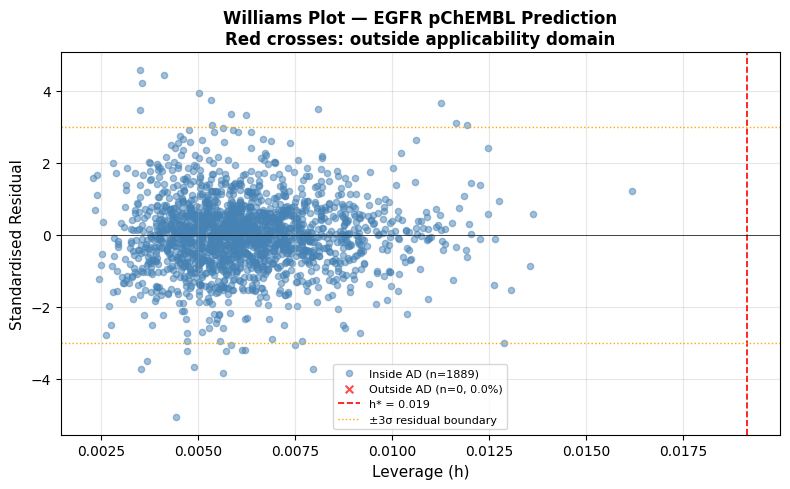

Saved part7_williams_plot.png


In [35]:
# ── Figure 1: Williams Plot ────────────────────────────────────────────────────
inside_ad  = h_test <= h_star
outside_ad = ~inside_ad

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(h_test[inside_ad],  std_residuals[inside_ad],
           alpha=0.5, s=20, color='steelblue', label=f'Inside AD (n={inside_ad.sum()})')
ax.scatter(h_test[outside_ad], std_residuals[outside_ad],
           alpha=0.7, s=30, color='red', marker='x',
           label=f'Outside AD (n={outside_ad.sum()}, {pct_outside:.1f}%)')

ax.axvline(h_star, color='red', linestyle='--', linewidth=1.2,
           label=f'h* = {h_star:.3f}')
ax.axhline( 3, color='orange', linestyle=':', linewidth=1,  label='±3σ residual boundary')
ax.axhline(-3, color='orange', linestyle=':', linewidth=1)
ax.axhline( 0, color='black',  linestyle='-', linewidth=0.5)

ax.set_xlabel('Leverage (h)', fontsize=11)
ax.set_ylabel('Standardised Residual', fontsize=11)
ax.set_title('Williams Plot — EGFR pChEMBL Prediction\n'
             'Red crosses: outside applicability domain',
             fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../figs/eda/part7_williams_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved part7_williams_plot.png')

In [36]:
# ── R² inside vs outside AD ───────────────────────────────────────────────────
if inside_ad.sum() > 5:
    r2_in  = r2_score(y_test[inside_ad],  y_pred[inside_ad])
    r2_out = r2_score(y_test[outside_ad], y_pred[outside_ad]) if outside_ad.sum() > 5 else np.nan
    print(f'R² inside  AD ({inside_ad.sum()} compounds) : {r2_in:.3f}')
    print(f'R² outside AD ({outside_ad.sum()} compounds): {r2_out:.3f}')

R² inside  AD (1889 compounds) : 0.734
R² outside AD (0 compounds): nan


---
## 4. Applicability Domain — Method 2: Tanimoto similarity

A more chemically intuitive AD: a test compound is inside the AD
if its maximum Tanimoto similarity to any training compound exceeds
a threshold (typically 0.4–0.6).

This directly encodes the medicinal chemistry intuition:
"the model is reliable for compounds similar to what it was trained on."

In [8]:
# Recompute RDKit bit-vector fingerprints (needed for BulkTanimotoSimilarity)
fps_train = [fpg.GetFingerprint(mols[i]) for i in train_idx if mols[i] is not None]
fps_test  = [fpg.GetFingerprint(mols[i]) for i in test_idx  if mols[i] is not None]

# For each test compound: maximum Tanimoto similarity to any training compound
TANIMOTO_THRESHOLD = 0.4   # compounds with max_sim < 0.4 are outside the Tanimoto AD

max_sim = np.array([
    max(DataStructs.BulkTanimotoSimilarity(fp_te, fps_train))
    for fp_te in fps_test
])

inside_tanimoto  = max_sim >= TANIMOTO_THRESHOLD
outside_tanimoto = ~inside_tanimoto

pct_in = 100 * inside_tanimoto.sum() / len(inside_tanimoto)
print(f'Tanimoto AD (threshold = {TANIMOTO_THRESHOLD})')
print(f'  Inside  AD: {inside_tanimoto.sum()} / {len(inside_tanimoto)} ({pct_in:.1f}%)')
print(f'  Outside AD: {outside_tanimoto.sum()} / {len(inside_tanimoto)} ({100-pct_in:.1f}%)')

if inside_tanimoto.sum() > 5 and outside_tanimoto.sum() > 5:
    r2_tan_in  = r2_score(y_test[:len(fps_test)][inside_tanimoto],
                           y_pred[:len(fps_test)][inside_tanimoto])
    r2_tan_out = r2_score(y_test[:len(fps_test)][outside_tanimoto],
                           y_pred[:len(fps_test)][outside_tanimoto])
    print(f'  R² inside  Tanimoto AD: {r2_tan_in:.3f}')
    print(f'  R² outside Tanimoto AD: {r2_tan_out:.3f}')

Tanimoto AD (threshold = 0.4)
  Inside  AD: 1840 / 1889 (97.4%)
  Outside AD: 49 / 1889 (2.6%)
  R² inside  Tanimoto AD: 0.741
  R² outside Tanimoto AD: 0.063


A coverture of the 97.4%, giben the size of the dataset and the trshold of 0.4 id realistic 

---

## 5. Figure 2 — UMAP Chemical Space

UMAP reduces the 2048-bit ECFP6 fingerprint space to two dimensions,
preserving local neighbourhood structure.

To aid interpretation, a kernel density estimate (KDE) is shown as a
background contour, highlighting regions of high chemical density.

**Panel A — Structural landscape (coloured by pChEMBL):**

* The background density (viridis colormap) represents the global distribution
  of compounds in chemical space.
* Individual compounds are coloured by pChEMBL (pIC50)
* High-potency compounds (pChEMBL > 8) are highlighted with larger markers
  and black edges.
* Test fold compounds are shown as unfilled circles.
* FDA-approved EGFR inhibitors (red stars) as references

**Panel B — Bioactivity class distribution:**

* Compounds are coloured by class: active (blue), inactive (orange),
  and intermediate (grey).
* Regions dominated by active compounds correspond to well-explored chemical
  series, while isolated inactive points often appear in low-density or
  peripheral regions of the space.

**What to look for:**

* High-density regions indicate common scaffolds or well-sampled areas of
  chemical space.
* Clustering of high-potency compounds suggests structure–activity relationships
  are locally consistent.
* FDA drugs located within dense active regions support the chemical relevance
  of the embedding.

---


In [37]:
print('Computing UMAP embedding... (may take 1-3 min)')
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='jaccard',    # Tanimoto for binary fingerprints
    random_state=42
)
embedding = reducer.fit_transform(X)
print(f'UMAP embedding shape: {embedding.shape}')

Computing UMAP embedding... (may take 1-3 min)
UMAP embedding shape: (9876, 2)


[03:54:47] Can't kekulize mol.  Unkekulized atoms: 5 6 7 8 25 26 27 28 29


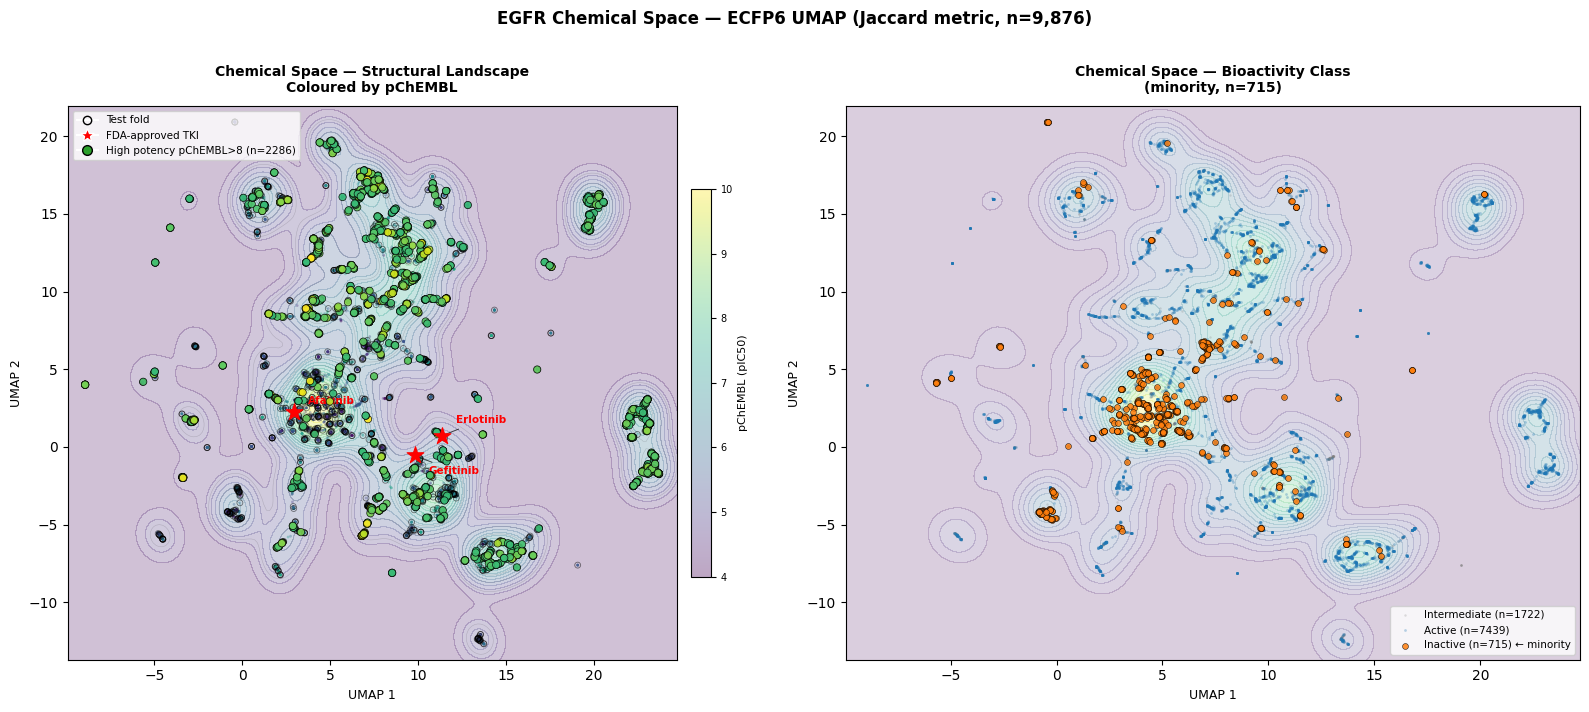

Saved part7_umap_chemical_space.png


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Precompute density for the background heatmap ────────────────────────────
xy = np.vstack([embedding[:, 0], embedding[:, 1]])
kde = gaussian_kde(xy, bw_method=0.15)

x_min, x_max = embedding[:, 0].min() - 1, embedding[:, 0].max() + 1
y_min, y_max = embedding[:, 1].min() - 1, embedding[:, 1].max() + 1
xx, yy = np.mgrid[x_min:x_max:200j, y_min:y_max:200j]
z = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)

# ── PANEL A: density + pChEMBL ─────────────────
ax = axes[0]

# KDE 
ax.contourf(xx, yy, z, levels=20, cmap='viridis', alpha=0.25)
ax.contour(xx, yy, z, levels=8, alpha=0.15, linewidths=0.4, colors='black')

sc = ax.scatter(
    embedding[:, 0], embedding[:, 1],
    c=y_reg, cmap='viridis',   
    s=4, alpha=0.35, linewidths=0,
    vmin=4, vmax=10, zorder=2
)

# (pChEMBL > 8) hightlight
high_mask = y_reg > 8
ax.scatter(
    embedding[high_mask, 0], embedding[high_mask, 1],
    c=y_reg[high_mask], cmap='viridis',
    s=28, alpha=0.9, linewidths=0.5,
    edgecolors='black', vmin=4, vmax=10, zorder=4,
    label=f'pChEMBL > 8 (n={high_mask.sum()})'
)

# Tets set
ax.scatter(
    embedding[test_idx, 0], embedding[test_idx, 1],
    s=18, facecolors='none', linewidths=0.6, 
    edgecolors='black', alpha=0.5, zorder=3, label='Test fold'
)

# FDA drugs — as red stars
FDA_DRUGS = {
    'Erlotinib'  : 'C#Cc1cccc(Nc2ncnc3cc(OCCO)c(OCCO)cc23)c1',
    'Gefitinib'  : 'COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCOCC1',
    'Osimertinib': 'C=CC(=O)Nc1cc2c(Nc3ccc(N(C)CCN(C)C)c(OC)c3)ncnc2cn1C',
    'Afatinib'   : 'C=CC(=O)N1CCC[C@@H]1c1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2c(OCC)c1',
}
fpg = rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=2048)
offsets = {'Erlotinib': (0.8, 0.8), 'Gefitinib': (0.8, -1.2),
           'Osimertinib': (-4, 0.8), 'Afatinib': (0.8, 0.5)}

for drug_name, smiles in FDA_DRUGS.items():
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        fp_arr = np.array(
            fpg.GetFingerprint(mol), dtype=np.float32
        ).reshape(1, -1)
        drug_xy = reducer.transform(fp_arr)[0]
        ax.scatter(*drug_xy, s=160, marker='*', zorder=6,
                   linewidths=0.8, color='red')   # rojo normal
        dx, dy = offsets.get(drug_name, (0.8, 0.8))
        ax.annotate(
            drug_name, drug_xy,
            xytext=(drug_xy[0] + dx, drug_xy[1] + dy),
            fontsize=7.5, fontweight='bold', color='red',
            arrowprops=dict(arrowstyle='-', lw=0.7, alpha=0.7)
        )

# colorbars
cb = plt.colorbar(sc, ax=ax, shrink=0.7, pad=0.02)
cb.set_label('pChEMBL (pIC50)', fontsize=8)
cb.ax.yaxis.set_tick_params(labelsize=7)

ax.set_title('Chemical Space — Structural Landscape\nColoured by pChEMBL',
             fontsize=10, fontweight='bold', pad=10)
ax.set_xlabel('UMAP 1', fontsize=9)
ax.set_ylabel('UMAP 2', fontsize=9)

#legends
legend_els = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='none',
           markeredgecolor='black', markersize=6, label='Test fold'),
    Line2D([0], [0], marker='*', color='w', markerfacecolor='red',
           markersize=10, label='FDA-approved TKI'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2ca02c',  
           markeredgecolor='black', markersize=7,
           label=f'High potency pChEMBL>8 (n={high_mask.sum()})'),
]
ax.legend(handles=legend_els, fontsize=7.5, loc='upper left')

# ── PANEL B: Biactivity class ──────────────────────
ax = axes[1]

# KDE 
ax.contourf(xx, yy, z, levels=20, cmap='viridis', alpha=0.20)

int_mask  = df_clean['bioactivity_class'] == 'intermediate'
act_mask  = df_clean['bioactivity_class'] == 'active'
inact_mask = df_clean['bioactivity_class'] == 'inactive'

# Intermediate
ax.scatter(embedding[int_mask, 0], embedding[int_mask, 1],
           c='gray', s=3, alpha=0.25, linewidths=0,
           zorder=2, label=f'Intermediate (n={int_mask.sum()})')

# Actives
ax.scatter(embedding[act_mask, 0], embedding[act_mask, 1],
           c='C0', s=4, alpha=0.30, linewidths=0,
           zorder=3, label=f'Active (n={act_mask.sum()})')

# Inactives
ax.scatter(embedding[inact_mask, 0], embedding[inact_mask, 1],
           c='C1', s=18, alpha=0.85, linewidths=0.4,
           edgecolors='black', zorder=5,
           label=f'Inactive (n={inact_mask.sum()}) ← minority')

ax.set_title('Chemical Space — Bioactivity Class\n(minority, n=715)',
             fontsize=10, fontweight='bold', pad=10)
ax.set_xlabel('UMAP 1', fontsize=9)
ax.set_ylabel('UMAP 2', fontsize=9)
ax.legend(fontsize=7.5, loc='lower right')

plt.suptitle('EGFR Chemical Space — ECFP6 UMAP (Jaccard metric, n=9,876)',
             fontsize=12, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('../figs/eda/part7_umap_chemical_space.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved part7_umap_chemical_space.png')

The reference drugs coincide with zones of high density. As we saw in notebook 2, the training data used drugs with similar properties to them.

The first figure shows a distribution of high pChEMBL values across the chemical space. In other words, drugs from a variety of structural families can be useful, and the model can work with them. At the same time, the second figure shows how the bioactivity class is also present across all different scaffolds, especially in the center, except for some clusters — the most prominent being the ones on the left.

---
## 6. Figure 3 — AD Coverage by Bioactivity Class

Are certain activity classes more likely to be outside the AD?
If all out-of-AD compounds are active, it may indicate that the
most potent scaffolds are underrepresented in the training data.

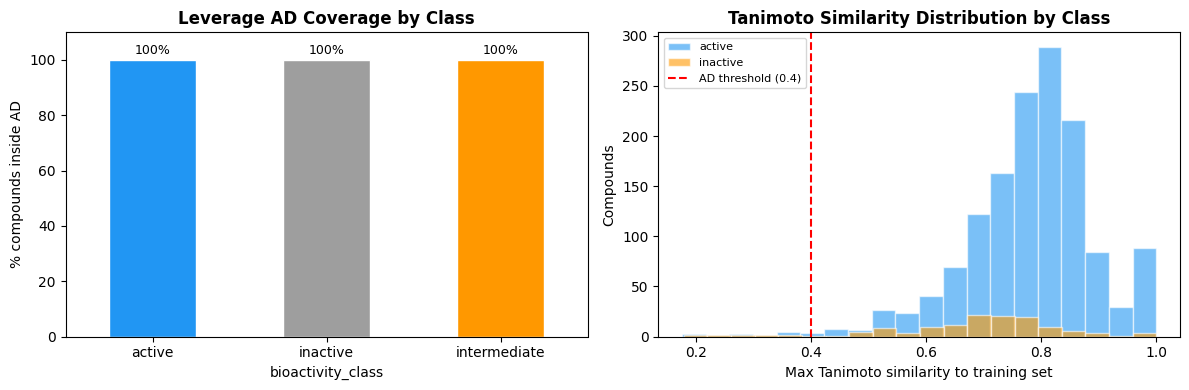

Saved part7_ad_coverage.png


In [25]:
# Combine AD flags with class labels for the test set
test_classes = df_clean.iloc[test_idx]['bioactivity_class'].values

ad_df = pd.DataFrame({
    'bioactivity_class': test_classes,
    'inside_leverage_AD': inside_ad,
    'max_tanimoto': max_sim[:len(test_idx)],
    'inside_tanimoto_AD': inside_tanimoto[:len(test_idx)],
    'y_true': y_test,
    'y_pred': y_pred,
    'residual': y_test - y_pred
})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Panel A: % inside AD by class (leverage)
ad_by_class = ad_df.groupby('bioactivity_class')['inside_leverage_AD'].mean() * 100
ad_by_class.plot(kind='bar', ax=axes[0], color=['#2196F3', '#9E9E9E', '#FF9800'],
                  edgecolor='white', rot=0)
axes[0].set_ylabel('% compounds inside AD')
axes[0].set_title('Leverage AD Coverage by Class', fontweight='bold')
axes[0].set_ylim(0, 110)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{bar.get_height():.0f}%', ha='center', va='bottom', fontsize=9)

# Panel B: Max Tanimoto similarity distribution by class
for cls, colour in [('active', '#2196F3'), ('inactive', '#FF9800')]:
    mask = ad_df['bioactivity_class'] == cls
    if mask.sum() > 0:
        axes[1].hist(ad_df.loc[mask, 'max_tanimoto'], bins=20, alpha=0.6,
                     color=colour, label=cls, edgecolor='white')
axes[1].axvline(TANIMOTO_THRESHOLD, color='red', linestyle='--',
                label=f'AD threshold ({TANIMOTO_THRESHOLD})')
axes[1].set_xlabel('Max Tanimoto similarity to training set')
axes[1].set_ylabel('Compounds')
axes[1].set_title('Tanimoto Similarity Distribution by Class', fontweight='bold')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('../figs/eda/part7_ad_coverage.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved part7_ad_coverage.png')

It appears all bioactivity clasees are cover in the AD.

---
## 7. Mini Virtual Screen

We query ChEMBL for EGFR compounds measured with **Ki** (binding affinity)
instead of IC50. These are structurally related but not in our training set
(which used only IC50 with `assay_type='B'`).

For each candidate:
1. Predict pChEMBL
2. Check if inside the Tanimoto AD
3. Rank by predicted pChEMBL (descending)

Only report predictions inside the AD — anything outside is flagged
as an extrapolation.

In [26]:
from chembl_webresource_client.new_client import new_client

print('Querying ChEMBL for EGFR Ki compounds (not in training set)...')

activity_client = new_client.activity
# Ki measurements give independent validation — different assay type
res = activity_client.filter(
    target_chembl_id='CHEMBL203',
    standard_type='Ki',
    assay_type='B'
)
df_ki = pd.DataFrame.from_dict(res)

# Apply the same quality filters as Part 1
df_ki = df_ki[
    df_ki['pchembl_value'].notnull() &
    (df_ki['potential_duplicate'] == 0) &
    (df_ki['standard_relation'].isin(['=', "'="]))
].copy()
df_ki['pchembl_value'] = pd.to_numeric(df_ki['pchembl_value'])

# Remove any that were already in our training set
df_ki = df_ki[~df_ki['molecule_chembl_id'].isin(mol_ids)].copy()

# Validate SMILES
df_ki['mol'] = df_ki['canonical_smiles'].apply(Chem.MolFromSmiles)
df_ki = df_ki[df_ki['mol'].notna()].copy()

# Deduplicate
print(f'Before dedup: {len(df_ki)} Ki compounds')
df_ki = df_ki.drop_duplicates(subset='molecule_chembl_id', keep='first')
print(f'After dedup: {len(df_ki)} unique Ki compounds')

Querying ChEMBL for EGFR Ki compounds (not in training set)...
Before dedup: 332 Ki compounds
After dedup: 221 unique Ki compounds


In [27]:
if len(df_ki) == 0:
    print('No Ki compounds found — using a small set of known inhibitors instead.')
    # Fallback: use known EGFR inhibitors from literature with confirmed activity
    fallback_smiles = [
        ('Lapatinib',    'CS(=O)(=O)CCNCc1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)o1'),
        ('Neratinib',    'C=CC(=O)Nc1cccc(Nc2ncnc3cc(Oc4ccc(N5CCN(C)CC5)cc4)c(Cl)cc23)c1'),
        ('Dacomitinib',  'C=CC(=O)N1CCC[C@@H]1c1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1OC'),
        ('Poziotinib',   'C=CC(=O)Nc1ccc2ncnc(Nc3ccc(OC)c(Cl)c3)c2c1'),
        ('Mobocertinib', 'CCC(=O)Nc1cc2c(Nc3cc(C)c(NC(=O)C=C)cc3OC)ncnc2cc1OC'),
        ('Canertinib',   'Cl.Cl.FC(F)(F)c1cc2c(Nc3ccc4c(cnn4Cc4ccccn4)c3)ncnc2cc1Br'),
    ]
    df_ki = pd.DataFrame(fallback_smiles, columns=['molecule_pref_name', 'canonical_smiles'])
    df_ki['pchembl_value'] = np.nan   # unknown — we're predicting these
    df_ki['mol'] = df_ki['canonical_smiles'].apply(Chem.MolFromSmiles)
    df_ki = df_ki[df_ki['mol'].notna()].copy()
    print(f'Using {len(df_ki)} fallback EGFR inhibitors')

In [28]:
X_df             = pd.read_csv('../data/processed/X_ecfp6.csv')
kept_cols        = X_df.drop(columns='molecule_chembl_id').columns.tolist()
kept_bit_indices = [int(c.split('_')[1]) for c in kept_cols]

# Featurize screening candidates — select only the 339 kept bits
screen_fps = [fpg.GetFingerprint(mol) for mol in df_ki['mol']]
screen_X   = np.array(
    [[list(fp)[i] for i in kept_bit_indices] for fp in screen_fps],
    dtype=np.float32
)

# ── Predict pChEMBL ───────────────────────────────────────────────────────────
screen_pred = model.predict(screen_X)

# ── AD check: max Tanimoto to training set ────────────────────────────────────
# Train on the FULL dataset for screening (not just fold 4)
model.fit(X, y_reg)
fps_all_train = [fpg.GetFingerprint(mol) for mol in mols if mol is not None]

screen_max_sim = np.array([
    max(DataStructs.BulkTanimotoSimilarity(fp, fps_all_train))
    for fp in screen_fps
])

# ── Build results table ───────────────────────────────────────────────────────
name_col = 'molecule_pref_name' if 'molecule_pref_name' in df_ki.columns else 'molecule_chembl_id'

screen_results = pd.DataFrame({
    'compound'         : df_ki[name_col].fillna(df_ki.get('molecule_chembl_id', 'unknown')).values,
    'predicted_pchembl': screen_pred.round(3),
    'experimental_pchembl': df_ki['pchembl_value'].values,
    'max_tanimoto_to_train': screen_max_sim.round(3),
    'inside_AD'        : (screen_max_sim >= TANIMOTO_THRESHOLD),
    'predicted_class'  : np.where(screen_pred >= 6.0, 'active',
                         np.where(screen_pred <= 5.0, 'inactive', 'intermediate')),
    'smiles'           : df_ki['canonical_smiles'].values,
}).sort_values('predicted_pchembl', ascending=False).reset_index(drop=True)

print('=== VIRTUAL SCREENING RESULTS ===')
print(screen_results[['compound', 'predicted_pchembl', 'experimental_pchembl',
                       'max_tanimoto_to_train', 'inside_AD',
                       'predicted_class']].to_string(index=False))

screen_results.to_csv('../data/results/part7_virtual_screen_hits.csv', index=False)
print('\nSaved part7_virtual_screen_hits.csv')

=== VIRTUAL SCREENING RESULTS ===
     compound  predicted_pchembl  experimental_pchembl  max_tanimoto_to_train  inside_AD predicted_class
 CHEMBL248221              7.823                  7.28                  0.916       True          active
CHEMBL6160966              7.792                  5.88                  0.652       True          active
CHEMBL6159659              7.737                  6.09                  0.644       True          active
CHEMBL4207425              7.706                  6.79                  1.000       True          active
CHEMBL4211782              7.634                  8.52                  0.750       True          active
CHEMBL4068763              7.467                  8.41                  0.714       True          active
CHEMBL4206604              7.174                  6.79                  0.830       True          active
CHEMBL3781993              7.131                  8.40                  0.360      False          active
CHEMBL4203072        

---
## 8. Figure 4 — Virtual Screen Results

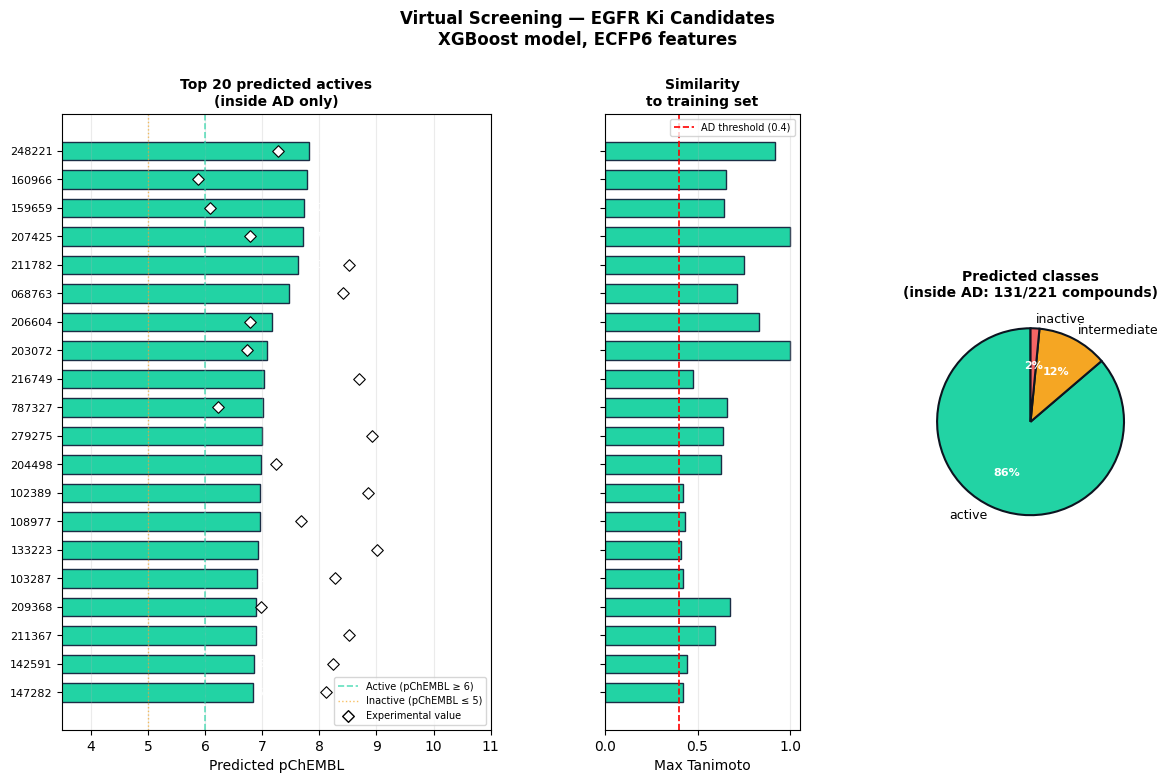

Showing top 20 inside-AD compounds of 221 screened


In [29]:
# ── Figure 4: Virtual Screen Results (top 20 only) ───────────────────────────
TOP_SHOW = 20

# Separate inside/outside AD and take top predicted
df_in  = screen_results[screen_results['inside_AD']].head(TOP_SHOW).copy()
df_out = screen_results[~screen_results['inside_AD']].head(5).copy()  # a few outside for context

# Use short labels — last part of CHEMBL ID or pref name
def short_label(row):
    name = str(row['compound'])
    if name.startswith('CHEMBL'):
        return name[-6:]   # e.g. CHEMBL3949 → '3949'
    return name[:18]       # truncate long names

df_in['label']  = df_in.apply(short_label, axis=1)
df_out['label'] = df_out.apply(short_label, axis=1)

fig = plt.figure(figsize=(14, 8))
gs  = fig.add_gridspec(1, 3, width_ratios=[2.2, 1, 1.2], wspace=0.4)

ax_main  = fig.add_subplot(gs[0])
ax_sim   = fig.add_subplot(gs[1])
ax_class = fig.add_subplot(gs[2])

# ── Panel A: Predicted pChEMBL — inside AD only ───────────────────────────────
colors_pred = ['#22d3a4' if v >= 6.0 else '#f5a623' if v >= 5.0 else '#f56565'
               for v in df_in['predicted_pchembl']]

bars = ax_main.barh(
    range(len(df_in)), df_in['predicted_pchembl'],
    color=colors_pred, edgecolor='#1a2d45', height=0.65
)

# Overlay experimental value if available
for i, (_, row) in enumerate(df_in.iterrows()):
    if pd.notna(row['experimental_pchembl']):
        ax_main.scatter(row['experimental_pchembl'], i,
                        marker='D', color='white', s=35, zorder=5,
                        edgecolors='black', linewidths=0.8)

ax_main.axvline(6.0, color='#22d3a4', linestyle='--', linewidth=1.2, alpha=0.7,
                label='Active (pChEMBL ≥ 6)')
ax_main.axvline(5.0, color='#f5a623', linestyle=':', linewidth=1.0, alpha=0.7,
                label='Inactive (pChEMBL ≤ 5)')
ax_main.scatter([], [], marker='D', color='white', edgecolors='black', s=35,
                label='Experimental value')

ax_main.set_yticks(range(len(df_in)))
ax_main.set_yticklabels(df_in['label'], fontsize=8)
ax_main.set_xlabel('Predicted pChEMBL', fontsize=10)
ax_main.set_title(f'Top {len(df_in)} predicted actives\n(inside AD only)',
                  fontweight='bold', fontsize=10)
ax_main.legend(fontsize=7, loc='lower right')
ax_main.set_xlim(3.5, 11)
ax_main.grid(axis='x', alpha=0.25)
ax_main.invert_yaxis()

# Add value labels
for bar, val in zip(bars, df_in['predicted_pchembl']):
    ax_main.text(val + 0.05, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}', va='center', fontsize=7.5, color='white')

# ── Panel B: Tanimoto similarity (inside AD top compounds) ────────────────────
sim_colors = ['#22d3a4' if s >= TANIMOTO_THRESHOLD else '#f56565'
              for s in df_in['max_tanimoto_to_train']]

ax_sim.barh(range(len(df_in)), df_in['max_tanimoto_to_train'],
            color=sim_colors, edgecolor='#1a2d45', height=0.65)
ax_sim.axvline(TANIMOTO_THRESHOLD, color='red', linestyle='--',
               linewidth=1.2, label=f'AD threshold ({TANIMOTO_THRESHOLD})')
ax_sim.set_yticks(range(len(df_in)))
ax_sim.set_yticklabels([])
ax_sim.set_xlabel('Max Tanimoto', fontsize=10)
ax_sim.set_title('Similarity\nto training set', fontweight='bold', fontsize=10)
ax_sim.set_xlim(0, 1.05)
ax_sim.legend(fontsize=7)
ax_sim.grid(axis='x', alpha=0.25)
ax_sim.invert_yaxis()

# ── Panel C: Class distribution summary (pie) ─────────────────────────────────
class_counts = screen_results[screen_results['inside_AD']]['predicted_class'].value_counts()
class_colors = {'active': '#22d3a4', 'intermediate': '#f5a623', 'inactive': '#f56565'}
pie_colors   = [class_colors.get(c, '#7a9ab5') for c in class_counts.index]

wedges, texts, autotexts = ax_class.pie(
    class_counts.values,
    labels=class_counts.index,
    colors=pie_colors,
    autopct='%1.0f%%',
    startangle=90,
    wedgeprops=dict(edgecolor='#0c1420', linewidth=1.5)
)
for t in texts:    t.set_fontsize(9)
for t in autotexts: t.set_fontsize(8); t.set_color('white'); t.set_fontweight('bold')

total_in = screen_results['inside_AD'].sum()
total    = len(screen_results)
ax_class.set_title(
    f'Predicted classes\n(inside AD: {total_in}/{total} compounds)',
    fontweight='bold', fontsize=10
)

plt.suptitle('Virtual Screening — EGFR Ki Candidates\nXGBoost model, ECFP6 features',
             fontweight='bold', fontsize=12, y=1.01)

plt.savefig('../figs/ad/virtual_screen.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f'Showing top {len(df_in)} inside-AD compounds of {total} screened')

## Virtual Screen overview
Of the 221 compunods 121 were inside the AD. The model reliably identifies active EGFR binders (86% hit rate within AD), and predicts moderate potency (pChEMBL 7.0–7.8)
with reasonable accuracy for compounds structurally similar to
the training set, we can recall how in the EDA we saw how the mayoritie of compunts had a pChEMBL values bwetenn 7 and 8. For highly potent compounds (pKi > 8),
predictions tend to be conservative. The rank-ordering within the
active class is partially preserved: the top-ranked compound
(CHEMBL248221, pred 7.82) shows the best absolute agreement
with experiment (exp 7.28).